IMPORTING REQUIRED LIBRARIES

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk as nlp
from nltk.stem.porter import PorterStemmer
nlp.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
! pip install wordcloud
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
! pip install xgboost
from xgboost import XGBClassifier
import pickle 
import re


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\akrityy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [34]:
%pip install worldcloud
%pip install xgboost
%pip install pickle
%pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement worldcloud (from versions: none)
ERROR: No matching distribution found for worldcloud


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.1
    Uninstalling scikit-learn-1.7.1:
      Successfully uninstalled scikit-learn-1.7.1
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


EXPLORATORY DATA ANALYSIS

In [24]:
# Load the dataset
import pandas as pd
data =  pd.read_csv(r"amazon_alexa.csv", delimiter= '\t', quoting=3)
print(f"Dataset shape: {data.shape}")

Dataset shape: (3150, 5)


In [16]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [17]:
# Column names
print(f"Column names:, {data.columns.values}")

Column names:, ['rating' 'date' 'variation' 'verified_reviews' 'feedback']


In [18]:
# Check for null values
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [19]:
# Letting the record where 'verified_reviews' is null
data[data['verified_reviews'].isna() == True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [20]:
# drop the null record
data.dropna(inplace= True)

In [21]:
print(f"Dataset shape after dropping null values: {data.shape}")

Dataset shape after dropping null values: (3149, 5)


In [22]:
# Creating a new column 'length' that will contain the length of the string in 'verified_reviews' column
data['length'] = data['verified_reviews'].apply(len)

In [23]:
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [27]:
# Randomly Checking for 10th record

# Ensure 'length' column exists
if 'length' not in data.columns:
	data['length'] = data['verified_reviews'].fillna('').apply(len)

# original value
print(f"'verified_reviews' column value: {data.iloc[10]['verified_reviews']}")
# Length of review using len()
print(f"Length of review: {len(data.iloc[10]['verified_reviews'])} characters")
# Value of the column length
print(f"'length' column value : {data.iloc[10]['length']}")

'verified_reviews' column value: "I sent it to my 85 year old Dad, and he talks to it constantly."
Length of review: 65 characters
'length' column value : 65


We can see that the length of review is the same as the value in the length column for that record.

# Datatypes of the features

In [31]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

Analyzing 'rating' column

This column refers to the rating of the variation given by the user.

In [32]:
# Distinct values of rating and its count

print(f"Rating value count: \n{data['rating'].value_counts()}")

Rating value count: 
rating
5    2286
4     455
1     161
3     152
2      96
Name: count, dtype: int64


Let's plot to visualize the total counts of each rating

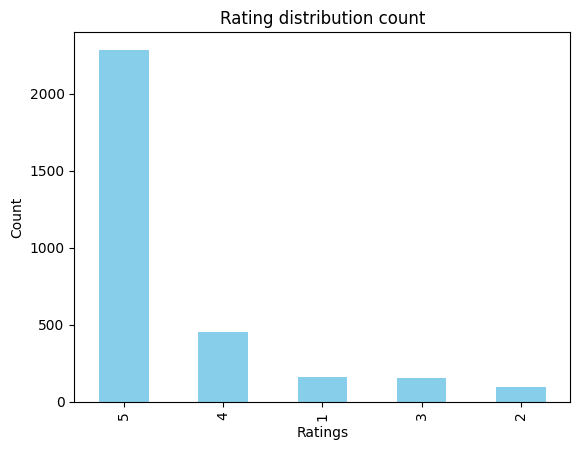

In [36]:
# Bar plot to visualize the total counts of each rating 

data['rating'].value_counts().plot.bar(color = 'skyblue')
plt.title('Rating distribution count')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

In [37]:
#finding the percentage distribution of each rating we'll divide the number of records for each rating by total number of records

print(f"Rating value count - percentage distribution: \n{round(data['rating'].value_counts()/data.shape[0]*100, 2)}")

Rating value count - percentage distribution: 
rating
5    72.57
4    14.44
1     5.11
3     4.83
2     3.05
Name: count, dtype: float64


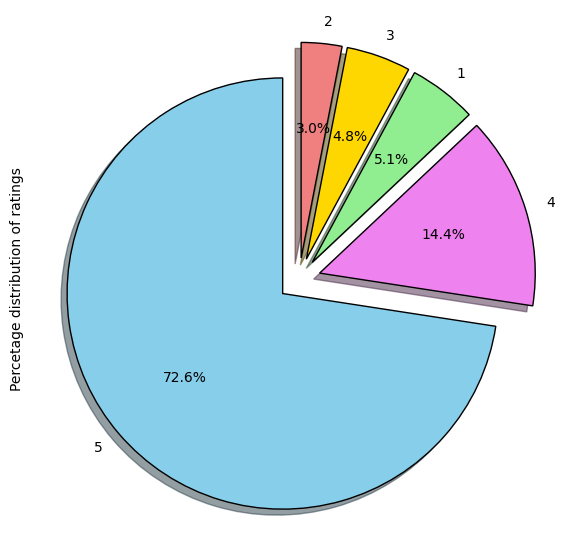

In [43]:
fig = plt.figure(figsize=(7,7))

colors = ('skyblue', 'violet', 'lightgreen', 'gold', 'lightcoral')

wp = { 'linewidth' : 1, 'edgecolor' : "black" }

tags = data['rating'].value_counts()/data.shape[0]

explode = [0.1] * len(tags)

tags.plot(kind='pie', autopct='%1.1f%%', shadow=True, colors=colors, startangle=90, wedgeprops=wp, explode=explode, label='Percetage distribution of ratings')

from io import BytesIO

graph = BytesIO()

fig.savefig(graph, format='png')

In [44]:
# Distinct values of feedback and its count

print(f"Feedback value count: \n{data['feedback'].value_counts()}")

Feedback value count: 
feedback
1    2893
0     257
Name: count, dtype: int64


There are 2 distinct values of 'feedback' present are 0 and -1. Let's see what kind of review each value corresponds to.

feedback value = 0

In [45]:
# Extracting the 'verified_reviews' value for one record with feedback = 0

review_0 = data[data['feedback'] == 0].iloc[1]['verified_reviews']
print(review_0)

Sound is terrible if u want good music too get a bose


In [47]:
# Extracting the 'verified_reviews' value for one record with feedback = 1

review_1 = data[data['feedback'] == 1].iloc[1]['verified_reviews']
print(review_1)

Loved it!


From the above 2 examples we can see that feedback 0 is negative review and 1 is positive review

Let's plot the feedback value count in a bar graph

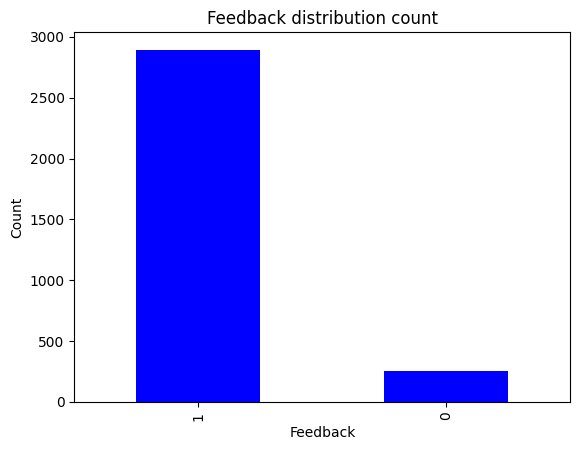

In [48]:
# Bar graph to visualize the total counts of each feedback 

data['feedback'].value_counts().plot.bar(color = 'blue')
plt.title('Feedback distribution count')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

In [49]:
# Finding the percentage distribution of each feedback - we'll divide the number of records for each feedback by total number 

print(f"Feedback value Count - percentage distribution: \n{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

Feedback value Count - percentage distribution: 
feedback
1    91.84
0     8.16
Name: count, dtype: float64


Feedback Distribution 

91.87% reviews are positive.  

8.17% reviews are negative.